In [1]:
import pickle
import numpy as np
from utils import root_path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

In [7]:
results = dict()
output_root = f'{root_path()}/results/spectral-clustering/'
list_methods = ['ista', 'fista', 'appr', 'appr-sor', 'cheby-poly']
list_datasets = ['as-skitter', 'cit-patent', 'com-dblp', 'com-lj', 'com-orkut',
                'com-youtube', 'ogbn-arxiv', 'ogbn-mag', 'ogbn-products', 'ogbn-proteins',
                'soc-lj1', 'soc-pokec', 'wiki-talk', 'ogbl-ppa', 'wiki-en21']
for method in list_methods:
    results[method] = {}
    for dataset in list_datasets:
        print(f'loading results from {method} and {dataset}')
        results[method][dataset] = pickle.load(open(output_root + 
                                   f'algo-{method}_datset-{dataset}_alpha-0.1_eps-1e-5_seed-17_num-sources-10000.pkl', 'rb'))

loading results from ista and as-skitter
loading results from ista and cit-patent
loading results from ista and com-dblp
loading results from ista and com-lj
loading results from ista and com-orkut
loading results from ista and com-youtube
loading results from ista and ogbn-arxiv
loading results from ista and ogbn-mag
loading results from ista and ogbn-products
loading results from ista and ogbn-proteins
loading results from ista and soc-lj1
loading results from ista and soc-pokec
loading results from ista and wiki-talk
loading results from ista and ogbl-ppa
loading results from ista and wiki-en21
loading results from fista and as-skitter
loading results from fista and cit-patent
loading results from fista and com-dblp
loading results from fista and com-lj
loading results from fista and com-orkut
loading results from fista and com-youtube
loading results from fista and ogbn-arxiv
loading results from fista and ogbn-mag
loading results from fista and ogbn-products
loading results from f

In [8]:
for method in list_methods:
    for ind, dataset in enumerate(list_datasets):
        results[method][dataset] = sorted(results[method][dataset],key=lambda x:x[0])

ista as-skitter [1.0, 0.8111888111888111, 0.8195718654434251, 0.8263254113345521, 0.8124542124542125]
ista cit-patent [1.0, 0.8333333333333334, 0.8, 0.7931034482758621, 0.7894736842105263]
ista com-dblp [1.0, 0.9130434782608695, 0.875, 0.813953488372093, 0.7407407407407407]
ista com-lj [1.0, 0.9824561403508771, 0.9712230215827338, 0.9518072289156626, 0.927461139896373]
ista com-orkut [1.0, 0.7647058823529411, 0.6695652173913044, 0.5920398009950248, 0.4530612244897959]
ista com-youtube [1.0, 0.8947368421052632, 0.8, 0.7142857142857143, 0.6363636363636364]
ista ogbn-arxiv [1.0, 0.6666666666666666, 0.5555555555555556, 0.5, 0.4666666666666667]
ista ogbn-mag [1.0, 0.9523809523809523, 0.9069767441860465, 0.8636363636363636, 0.8222222222222222]
ista ogbn-products [1.0, 0.8823529411764706, 0.8333333333333334, 0.75, 0.6744186046511628]
ista ogbn-proteins [1.0, 0.8181818181818182, 0.625, 0.45454545454545453, 0.2857142857142857]
ista soc-lj1 [1.0, 0.9900497512437811, 0.9871794871794872, 0.9858156

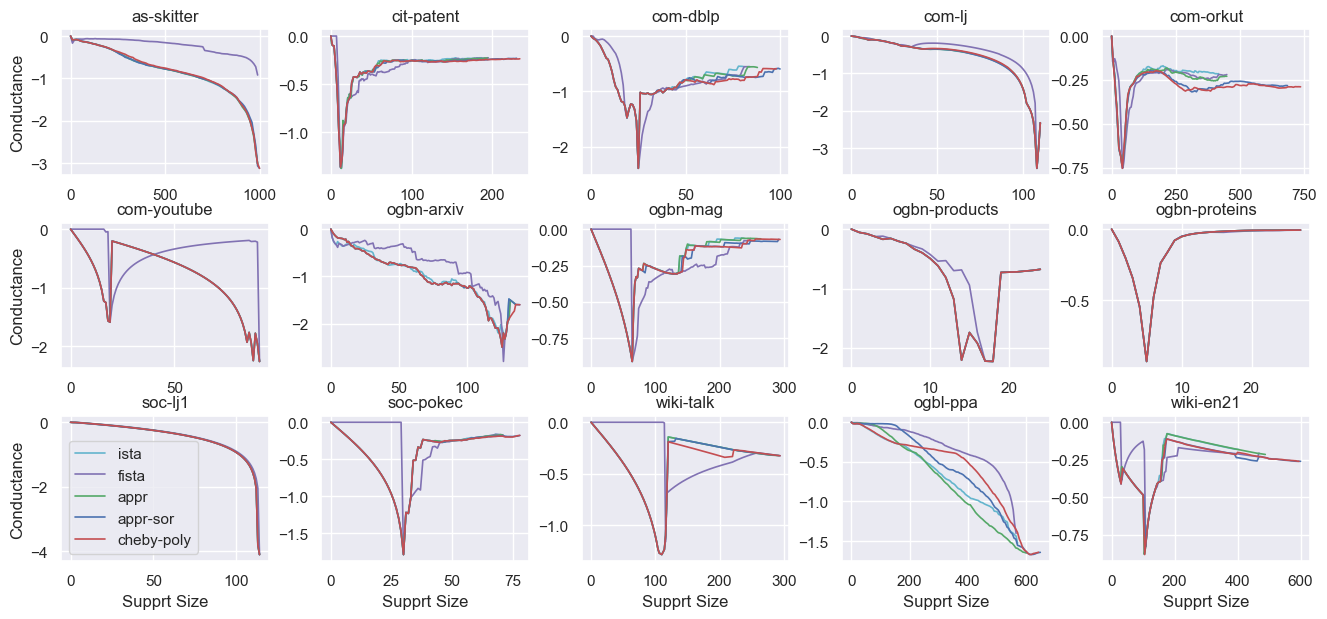

In [9]:
c_list = ['c', 'm', 'g', 'b', 'r']
marker_list = ['D', 'H', 's', 'o', 'x']
fig, ax = plt.subplots(3, 5,figsize=(13, 6))
for i, method in enumerate(list_methods):
    for ind, dataset in enumerate(list_datasets):
        ii = int(ind / 5)
        jj = ind % 5
        min_conduct, cluster_re, len_nonzeros, vol_supp_xt, total_opers, run_time = results[method][dataset][0]
        conducts, node_vol = cluster_re
        print(method, dataset, conducts[:5])
        ax[ii,jj].plot(node_vol, np.log10(conducts), linewidth=1.2, label=method, c=c_list[i])
        ax[ii,jj].set_title(dataset)
        ax[2,jj].set_xlabel('Support Size')
        ax[ii,0].set_ylabel('Conductance')
ax[2][0].legend()
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig('figs/figs_spectral-clustering-conductance.pdf')